In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "Z001_Results_Analizer":
    ROOT = ROOT.parent

SIM_SETS = {
    "Random mesh": [100, 101, 102, 103],
    "Hexagonal packing": [200, 201, 202, 203],
}


def count_inp_nodes_elements(sim):
    inp_path = ROOT / "E001_Simulations" / f"SIM_{sim}" / f"SIM_{sim}.inp"
    in_nodes = False
    in_elements = False
    n_nodes = 0
    n_elements = 0

    with inp_path.open("r", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line or line.startswith("**"):
                continue
            if line.startswith("*"):
                lower = line.lower()
                in_nodes = lower.startswith("*node") and "nset=foam" in lower
                in_elements = lower.startswith("*element")
                continue
            if in_nodes:
                n_nodes += 1
            if in_elements:
                n_elements += 1

    return n_nodes, n_elements


rows = []
for mesh_type, sims in SIM_SETS.items():
    for sim in sims:
        n_nodes, n_elements = count_inp_nodes_elements(sim)
        rows.append({
            "mesh_type": mesh_type,
            "sim": sim,
            "nodes": n_nodes,
            "elements": n_elements,
        })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except ImportError:
    for row in rows:
        print(row)


,mesh_type,sim,nodes,elements
0,Random mesh,100,17821,15399
1,Random mesh,101,8977,7308
2,Random mesh,102,4391,3337
3,Random mesh,103,1677,1200
4,Hexagonal packing,200,18072,15620
5,Hexagonal packing,201,2252,1720
6,Hexagonal packing,202,11050,9432
7,Hexagonal packing,203,2433,1865


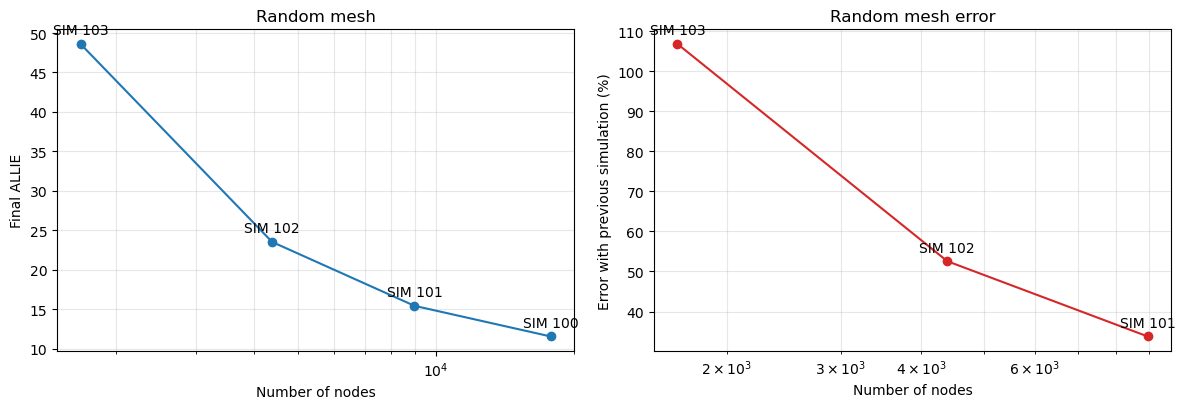

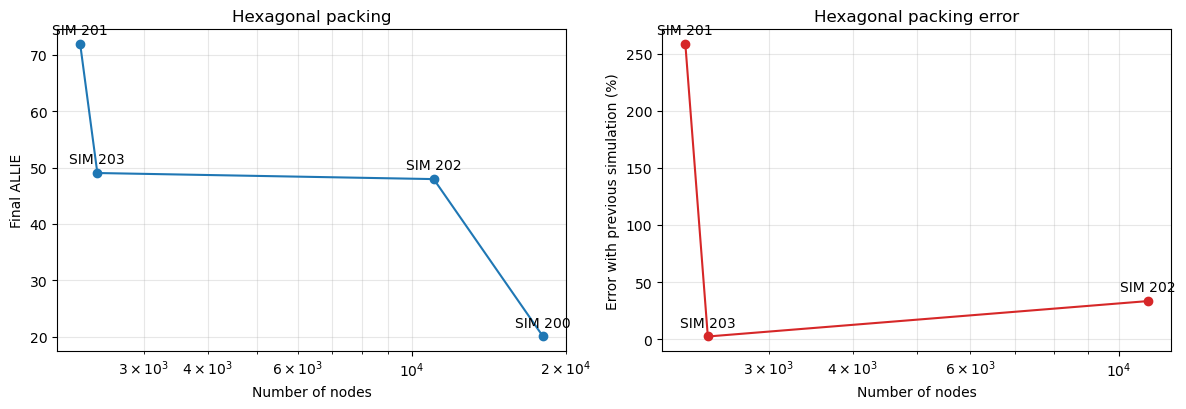

In [2]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "Z001_Results_Analizer":
    ROOT = ROOT.parent

SIM_SETS = {
    "Random mesh": [100, 101, 102, 103],
    "Hexagonal packing": [200, 201, 202, 203],
}


def count_foam_nodes(sim):
    inp_path = ROOT / "E001_Simulations" / f"SIM_{sim}" / f"SIM_{sim}.inp"
    in_foam_nodes = False
    n_nodes = 0

    with inp_path.open("r", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line or line.startswith("**"):
                continue
            if line.startswith("*"):
                lower = line.lower()
                in_foam_nodes = lower.startswith("*node") and "nset=foam" in lower
                continue
            if in_foam_nodes:
                n_nodes += 1

    return n_nodes


def final_allie(sim):
    pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim}_A.pkl"
    with pkl_path.open("rb") as f:
        data = pickle.load(f)
    return data["ALLIE"]["ASSEMBLY"][-1]


for title, sims in SIM_SETS.items():
    data = [(sim, count_foam_nodes(sim), final_allie(sim)) for sim in sims]
    points = sorted((nodes, value, sim) for sim, nodes, value in data)
    nodes = [p[0] for p in points]
    allie = [p[1] for p in points]

    error_data = []
    for previous, current in zip(data, data[1:]):
        sim, n_nodes, value = current
        previous_value = previous[2]
        error = abs((value - previous_value) / previous_value) * 100
        error_data.append((n_nodes, error, sim))
    error_points = sorted(error_data)

    fig, (ax_allie, ax_error) = plt.subplots(1, 2, figsize=(12, 4.2))

    ax_allie.plot(nodes, allie, marker="o")
    ax_allie.set_xscale("log")
    ax_allie.set_xlabel("Number of nodes")
    ax_allie.set_ylabel("Final ALLIE")
    ax_allie.set_title(title)
    ax_allie.grid(True, which="both", alpha=0.3)

    for n_nodes, value, sim in points:
        ax_allie.annotate(f"SIM {sim}", (n_nodes, value), xytext=(0, 7), textcoords="offset points", ha="center")

    ax_error.plot([p[0] for p in error_points], [p[1] for p in error_points], marker="o", color="tab:red")
    ax_error.set_xscale("log")
    ax_error.set_xlabel("Number of nodes")
    ax_error.set_ylabel("Error with previous simulation (%)")
    ax_error.set_title(f"{title} error")
    ax_error.grid(True, which="both", alpha=0.3)

    for n_nodes, error, sim in error_points:
        ax_error.annotate(f"SIM {sim}", (n_nodes, error), xytext=(0, 7), textcoords="offset points", ha="center")

    plt.tight_layout()
    plt.show()


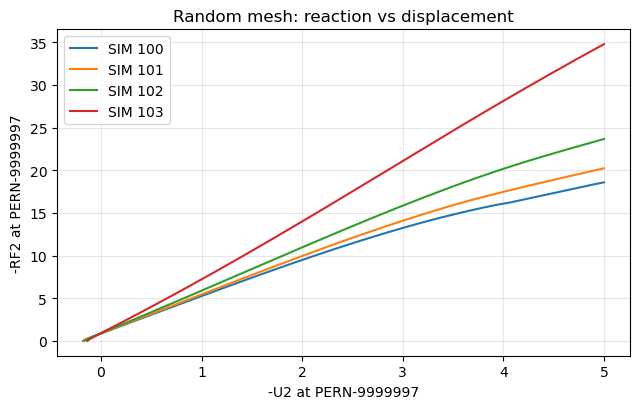

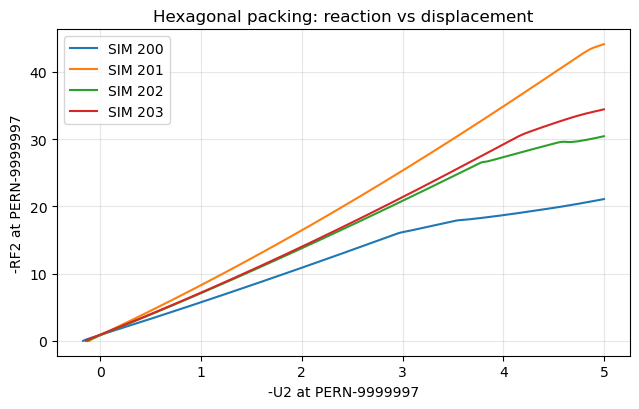

In [3]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "Z001_Results_Analizer":
    ROOT = ROOT.parent

SIM_SETS = {
    "Random mesh": [100, 101, 102, 103],
    "Hexagonal packing": [200, 201, 202, 203],
}


def node_history(data, field, nset="PERN-9999997", node="9999997"):
    values = data[field][nset]
    if isinstance(values, dict):
        values = values[node]
    return values


for title, sims in SIM_SETS.items():
    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    for sim in sims:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim}_A.pkl"
        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        displacement = [-value for value in node_history(data, "U2")]
        reaction = [-value for value in node_history(data, "RF2")]
        ax.plot(displacement, reaction, label=f"SIM {sim}")

    ax.set_xlabel("-U2 at PERN-9999997")
    ax.set_ylabel("-RF2 at PERN-9999997")
    ax.set_title(f"{title}: reaction vs displacement")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


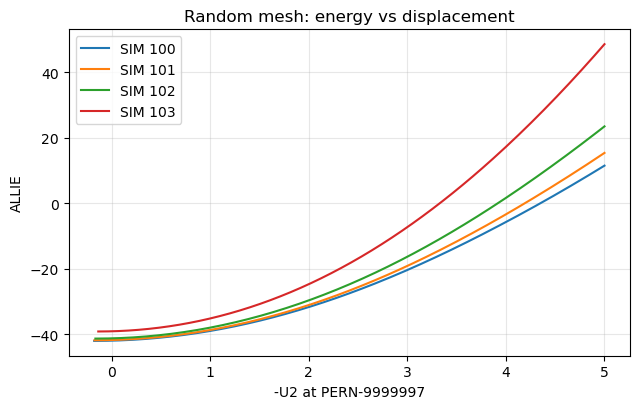

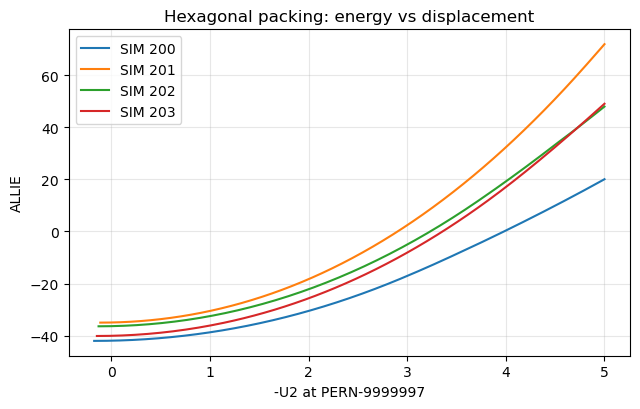

In [4]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "Z001_Results_Analizer":
    ROOT = ROOT.parent

SIM_SETS = {
    "Random mesh": [100, 101, 102, 103],
    "Hexagonal packing": [200, 201, 202, 203],
}


def node_history(data, field, nset="PERN-9999997", node="9999997"):
    values = data[field][nset]
    if isinstance(values, dict):
        values = values[node]
    return values


for title, sims in SIM_SETS.items():
    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    for sim in sims:
        pkl_path = ROOT / "I001_Results" / f"DATA_PICK_{sim}_A.pkl"
        with pkl_path.open("rb") as f:
            data = pickle.load(f)

        displacement = [-value for value in node_history(data, "U2")]
        energy = data["ALLIE"]["ASSEMBLY"]
        ax.plot(displacement, energy, label=f"SIM {sim}")

    ax.set_xlabel("-U2 at PERN-9999997")
    ax.set_ylabel("ALLIE")
    ax.set_title(f"{title}: energy vs displacement")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
